# 1. Linear Regression using Normal Form

source : https://youtu.be/plIWtQq0-Xo?list=PLVyM62CSsh3WXGKbhLY1AsIi2_e-2vl6U

## Normal Equation

**The Normal Equation is closed-form solution to linear regression. Instead of iterating, it computes the optimal weights w directly in single step.**

**The Formula**

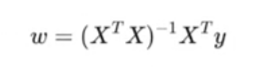



Question: Write a Python function that performs linear regression using the normal equation. The function should take a matrix X (features) and a vector y (target) as input, and return the coefficient of the linear regression model. Round your answer to four decimal places, -0.0 is a valid result for rounding a very small number.

In [1]:
import numpy as np

In [2]:
class LinearRegressionNormal:
    def __init__(self):
        self.theta = None

    def fit(self, X: list[list[float]], y: list[float]):
        X = np.array(X)
        y = np.array(y)
        self.theta = np.linalg.inv(X.T @ X) @ X.T @ y
        return self

    def predict(self, X:list[list[float]]) -> np.ndarray:
        X = np.array(X)
        return np.round(X @ self.theta, 4)

In [7]:
# Test Case 1

model = LinearRegressionNormal()
model.fit([[1,1], [1,2], [1, 3]], [1, 2, 3])
print("Coefficient(Bias/y-intercept, Slope):", np.round(model.theta, 4).tolist())
print("Predictions:", model.predict([[1,1], [1, 2], [1, 3]]))

Coefficient(Bias/y-intercept, Slope): [-0.0, 1.0]
Predictions: [1. 2. 3.]


In [6]:
# Test Case 2

model = LinearRegressionNormal()
model.fit([[1,3, 4], [1, 2, 5], [1, 3, 2]], [1, 2, 1])
print("Coefficient(Bias, Slope1/weight1, slop2/weight2):", np.round(model.theta, 4).tolist())
print("Predictions:", model.predict([[1,3, 4], [1, 2, 5], [1, 3, 2]]))

Coefficient(Bias, Slope): [4.0, -1.0, -0.0]
Predictions: [1. 2. 1.]


## Gradient Descent

**Gradient Descent is an iterative optimization algorithm. Instead of solving for w analytically, it starts from w = 0 and repetedly nudges the weights in the direction that reduces the loss.**
                                                                                                            
### Loss Function : Mean Seqared Error(MSE)
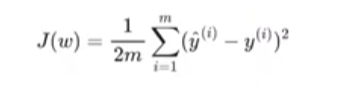


### The Gradient
Differenting J with respect to each weight wj:
(predection error x feature value)  across all samples
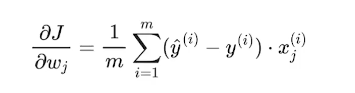

### The Update Rule
All weights are updated simultaneously after computing the full-batch gradient.
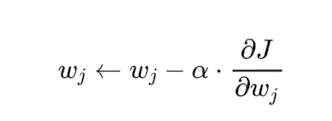



## 3 Ways to implement 

1. 3-loop : Fully explicit: iterate over epochs -> features -> samples
2. 2-loop : use np.sum to aggregate over all m samples at ones
3. 1-loop : one matrix multiply updates all wj simultaneously

Q: 
Write a python function that performs linear regression using gradient descent. The function should take Numpy arrays X(features with a column of ones for the intercept) and y(target) as input, along with learning rate alpha and the number of iterations. Return the learned coefficients(weights) as NumPy array. 

In [15]:
# using 3 loop implementation
class LinearRegressionGD3Loop:
    def __init__(self, alpha: float = 0.01, iterations: int = 1000):
        self.alpha = alpha
        self.iterations = iterations
        self.theta = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        m, n = X.shape # m(numbers of training examples(rows)) & n(numbers of features(columns))
        y = y.reshape(-1, 1) # change to 2d
        self.theta = np.zeros((n,1)) # initialize all weights/slops to zero

        for _ in range(self.iterations):
            # Loop1
            # What: it Repets the entire learning process
            # Why: Each iteration improves the weights slightly
            for j in range(n):
                # Loop2
                # What: Updates each weight one at a time
                # Why: Each feature needs its own coefficient(bias, weight1, weight2,...)
                gradient_sum = 0
                # What: Restarts the sum for this specific weight
                # Why: Starts fresh for calculating the gradient for w(theta)j
                for i in range(m):
                    # Loop 3
                    # What: Loop through every data point
                    # Why: Gradient depends on the error across all examples
                    prediction = X[i] @ self.theta
                    # What: Calculates prediction for example i
                    # How: Dot products between features and current weights
                    error = prediction - y[i]
                    # What: How far off our predection was
                    # Positive Error: Predected too high
                    # Negative Error: Predected too low
                    gradient_sum += error * X[i, j]
                    # What: The core of gradient descent calculation
                gradient = (1/m) * gradient_sum
                # What: Averages the gradient sum
                # Why: So step size doesn't depend on number of exmples
                self.theta[j] = self.theta[j] - self.alpha * gradient
                # What: Updates the weight
                # Why: Move weight in direction that reduces error
        return self
        # Returns the trained model
    def predict(self, X: np.ndarray) -> np.ndarray:
        # Makes predection on new data using trained weights
        return (X @ self.theta).flatten()

In [17]:
# Test Case 1
model = LinearRegressionGD3Loop(alpha=0.1, iterations=1000)
model.fit(np.array([[1, 1], [1, 2], [1, 3]]), np.array([3, 5, 7]))
print("Coefficients:", np.round(model.theta.flatten(), 4))
print("Predictions:", np.round(model.predict(np.array([[1, 1], [1, 2], [1, 3]]))))


# Test Case 2
model = LinearRegressionGD3Loop(alpha=0.01, iterations=2000)
model.fit(np.array([[1, 3, 4], [1, 2, 5], [1, 3, 2]]), np.array([1, 2, 1]))
print("Coefficients:", np.round(model.theta.flatten(), 4))
print("Predictions:", np.round(model.predict(np.array([[1, 3, 4], [1, 2, 5], [1, 3, 2]]))))


Coefficients: [1. 2.]
Predictions: [3. 5. 7.]
Coefficients: [ 0.4863 -0.1105  0.3056]
Predictions: [1. 2. 1.]


In [23]:
# using 2 loop implementation (vectorized over samples)
class LinearRegressionGD2Loop:
    def __init__(self, alpha: float = 0.01, iterations: int = 1000):
        self.alpha = alpha
        self.iterations = iterations
        self.theta = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        m, n = X.shape  # m=number of examples, n=number of features
        y = y.reshape(-1, 1)  # Convert to column vector
        self.theta = np.zeros((n,1)) # Initialize weights to zero
        
        for _ in range(self.iterations):
            # LOOP 1: ITERATIONS (same as 3-loop)
            
            # Calculate predictions and errors for ALL samples at once
            predictions = X @ self.theta  # Shape: (m, 1)
            errors = predictions - y      # Shape: (m, 1)
            
            # LOOP 2: FEATURES (update each weight one by one)
            for j in range(n):
                # Calculate gradient for feature j using ALL samples
                # np.sum replaces the entire inner loop over i (samples)
                gradient = (1 / m) * np.sum(errors * X[:, j].reshape(-1, 1))
                
                # Update weight j using gradient descent
                self.theta[j] = self.theta[j] - self.alpha * gradient
                
        return self
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        return (X @ self.theta).flatten()

In [26]:
# using 1 loop implementation (fully vectorized)
class LinearRegressionGD1Loop:
    def __init__(self, alpha: float = 0.01, iterations: int = 1000):
        self.alpha = alpha
        self.iterations = iterations
        self.theta = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        m, n = X.shape
        y = y.reshape(-1, 1) 
        self.theta = np.zeros((n,1))  
        # STEP 4: Learning loop (ONLY 1 LOOP!)
        for iteration in range(self.iterations):
            # Part 1: Calculate predictions for ALL examples
            predictions = X @ self.theta  # Shape: (m, 1)
            # 3-LOOP: Had to calculate prediction for each i: X[i] @ theta
            
            # Part 2: Calculate errors for ALL examples
            errors = predictions - y  # Shape: (m, 1)
            # 3-LOOP: Had to calculate error for each i: prediction - y[i]
            
            # Part 3: Calculate gradient for ALL features at once
            gradient_sum = X.T @ errors  # Shape: (n, 1)
            # 3-LOOP: Had to sum over i for each j: Σ error × X[i,j]
            # 2-LOOP: Had to do this for each j: np.sum(errors * X[:,j])
            # 1-LOOP: ONE matrix multiplication replaces ALL j loops!
            
            # Part 4: Average the gradient
            gradient = (1 / m) * gradient_sum  # Shape: (n, 1)
            # ALL versions do this step
            
            # Part 5: Update ALL weights at once
            self.theta = self.theta - self.alpha * gradient
            # 3-LOOP: Updated each theta[j] one by one
            # 2-LOOP: Updated each theta[j] one by one
            # 1-LOOP: Updates ALL theta in ONE operation!
        return self
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        # Make predictions using trained weights
        return (X @ self.theta).flatten()

In [27]:
# Test Case 1 - Perfect line
model = LinearRegressionGD1Loop(alpha=0.1, iterations=1000)
model.fit(np.array([[1, 1], [1, 2], [1, 3]]), np.array([3, 5, 7]))
print("Test Case 1 - y = 2x + 1")
print("Coefficients (bias, slope):", np.round(model.theta.flatten(), 4))
print("Predictions:", np.round(model.predict(np.array([[1, 1], [1, 2], [1, 3]])), 4))

Test Case 1 - y = 2x + 1
Coefficients (bias, slope): [1. 2.]
Predictions: [3. 5. 7.]
Expected: [1, 2] and [3, 5, 7]
--------------------------------------------------
